# Analysis of the docking scores

In [12]:
from rdkit import Chem
from rdkit.Chem import Draw
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
dock_df = pd.read_csv("../data/results.csv")
similarity_df = pd.read_csv(
    "../screening/similarity_scores.csv", names=["smiles", "similarity"]
)
similarity_df["id"] = similarity_df["smiles"].apply(lambda x: x.split("\t")[1])
similarity_df["smiles"] = similarity_df["smiles"].apply(lambda x: x.split("\t")[0])

df = similarity_df.merge(dock_df, left_on="smiles", right_on="orig_smiles")
df.describe()

,similarity,mmgbsa_score,mmgbsa_score_sem,mmpbsa_score,mmpbsa_score_sem,vina_score
count,57948.000000,57948.000000,57948.000000,57948.000000,57948.000000,57948.000000
mean,0.483788,-30.728149,0.505871,-24.731866,0.418253,-8.352451
std,0.092066,6.191422,0.221009,5.001953,0.174387,0.926589
min,0.404762,-54.684265,0.089525,-44.423265,0.091001,-11.909000
25%,0.411765,-34.840389,0.348981,-28.128965,0.296080,-9.103000
50%,0.432432,-31.121701,0.460647,-25.181928,0.382094,-8.266000
75%,0.567568,-27.038785,0.611379,-21.936227,0.500628,-7.631000
max,0.862069,3.037913,2.222869,0.114055,2.172281,-5.257000


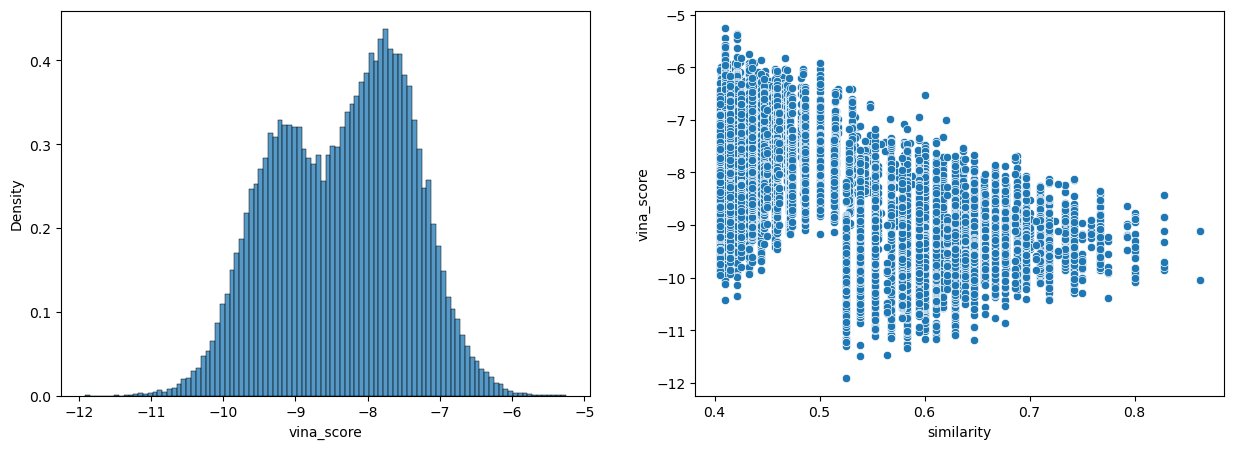

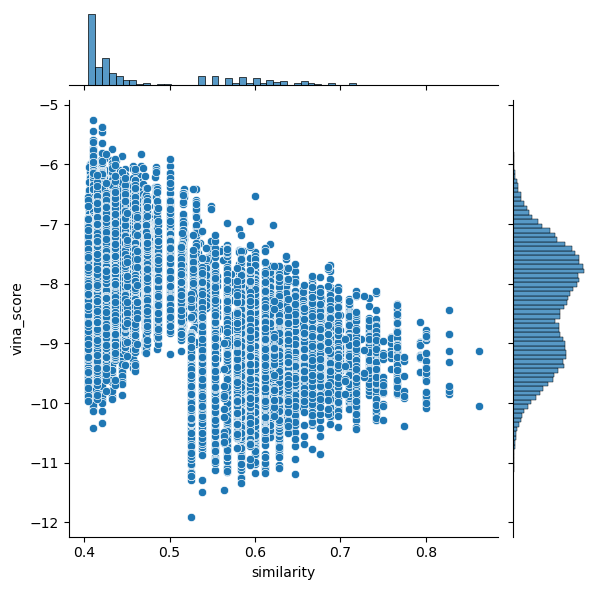

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df, x="vina_score", ax=ax1, stat="density", bins=100)
sns.scatterplot(df, x="similarity", y="vina_score", ax=ax2)
sns.jointplot(df, x="similarity", y="vina_score")

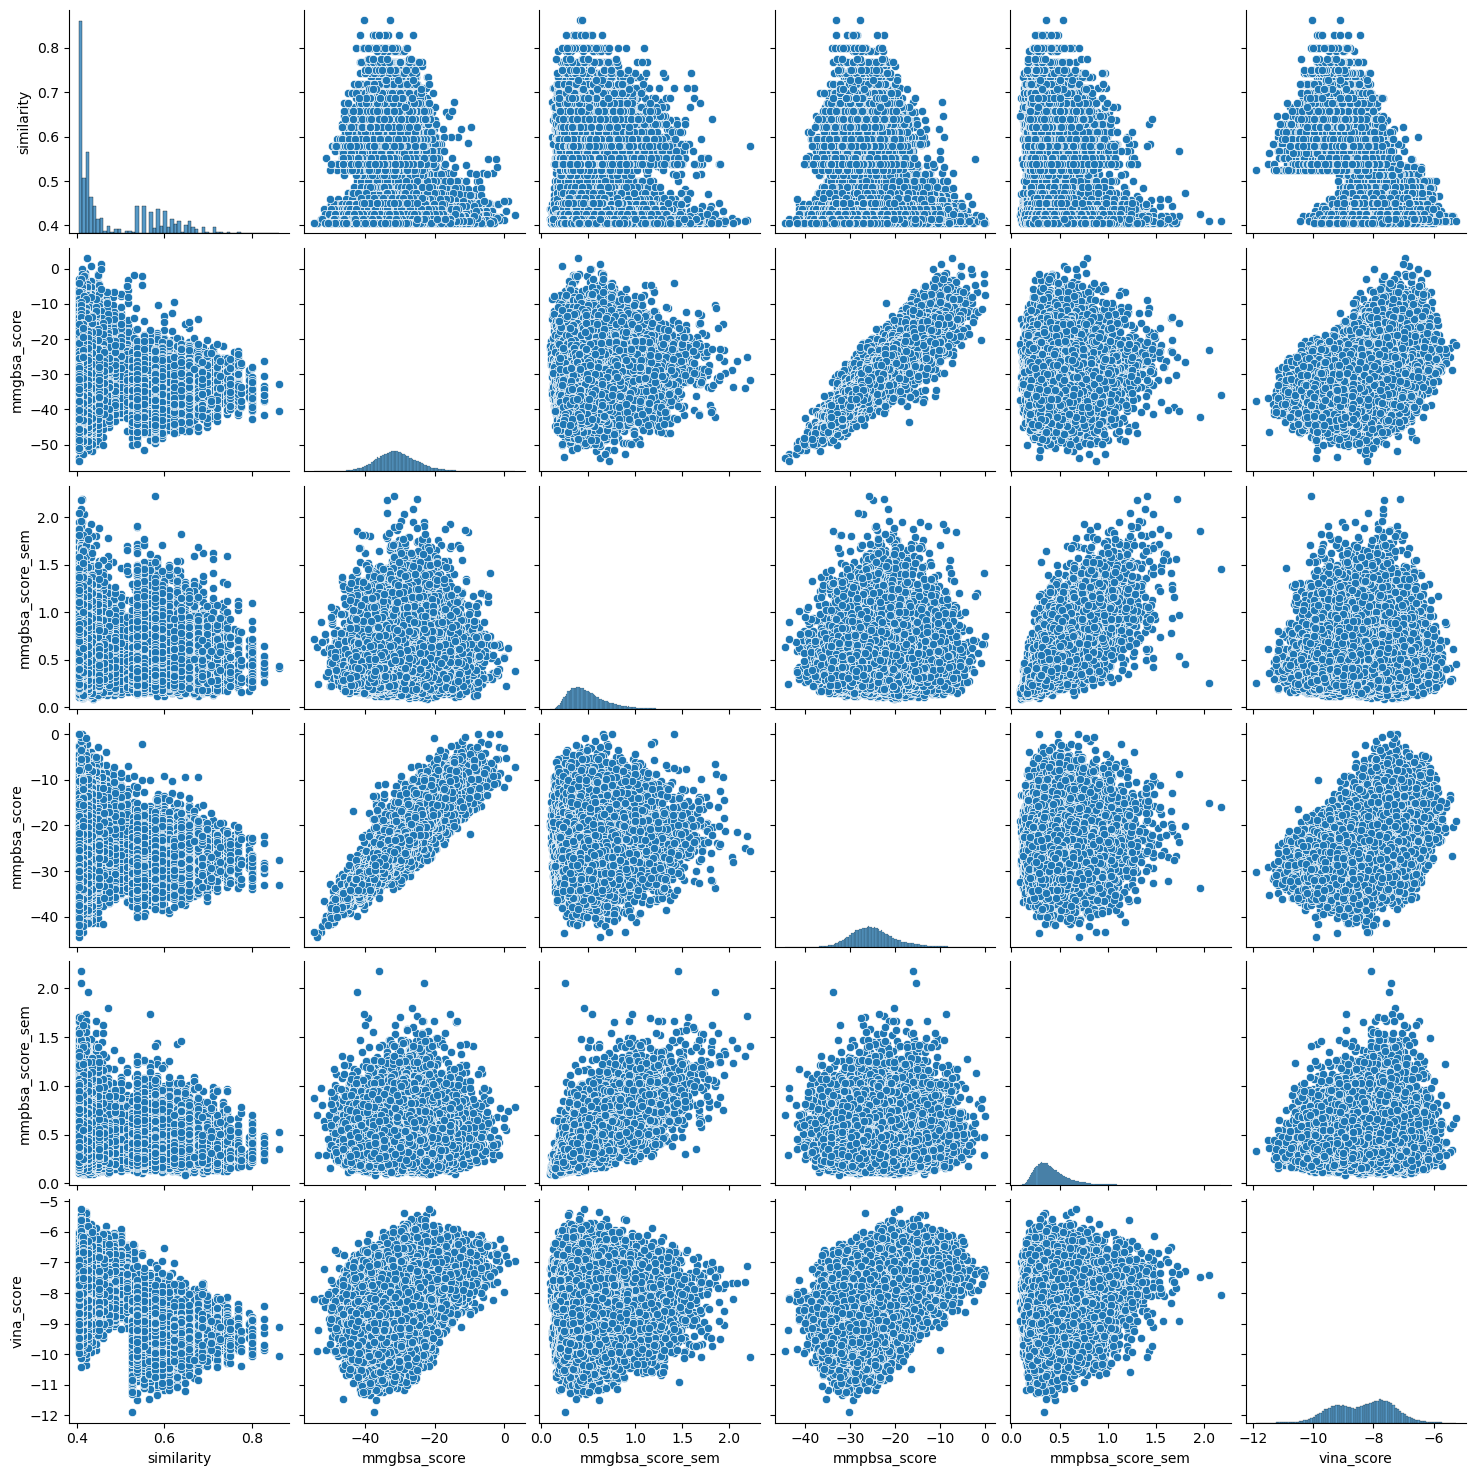

In [15]:
sns.pairplot(df)

We observe a large improvement in the docking scores as the similarity increases. This is confirmed by the correlation.

In [16]:
df[["similarity", "vina_score"]].corr(method="pearson")

,similarity,vina_score
similarity,1.000000,-0.679059
vina_score,-0.679059,1.000000


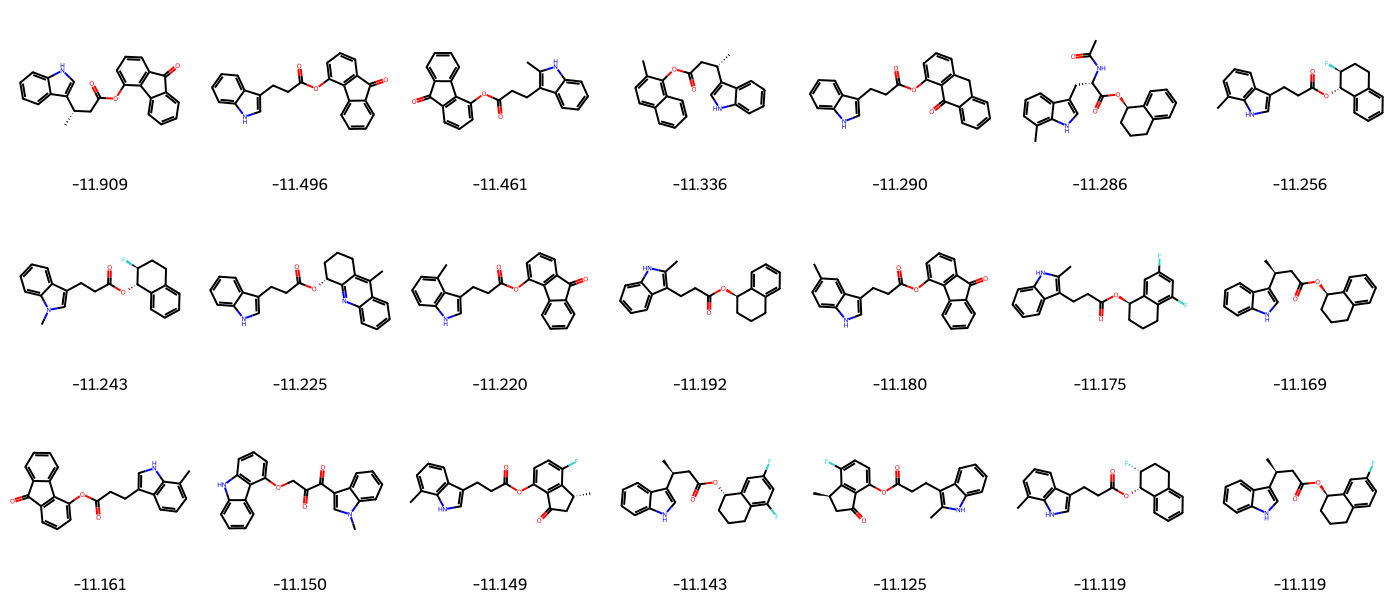

In [17]:
best = df.nsmallest(21, columns="vina_score")
mols = best["smiles"].map(Chem.MolFromSmiles)
Draw.MolsToGridImage(
    mols,
    molsPerRow=7,
    legends=best["vina_score"].apply(lambda x: f"{x:.3f}").tolist(),
)

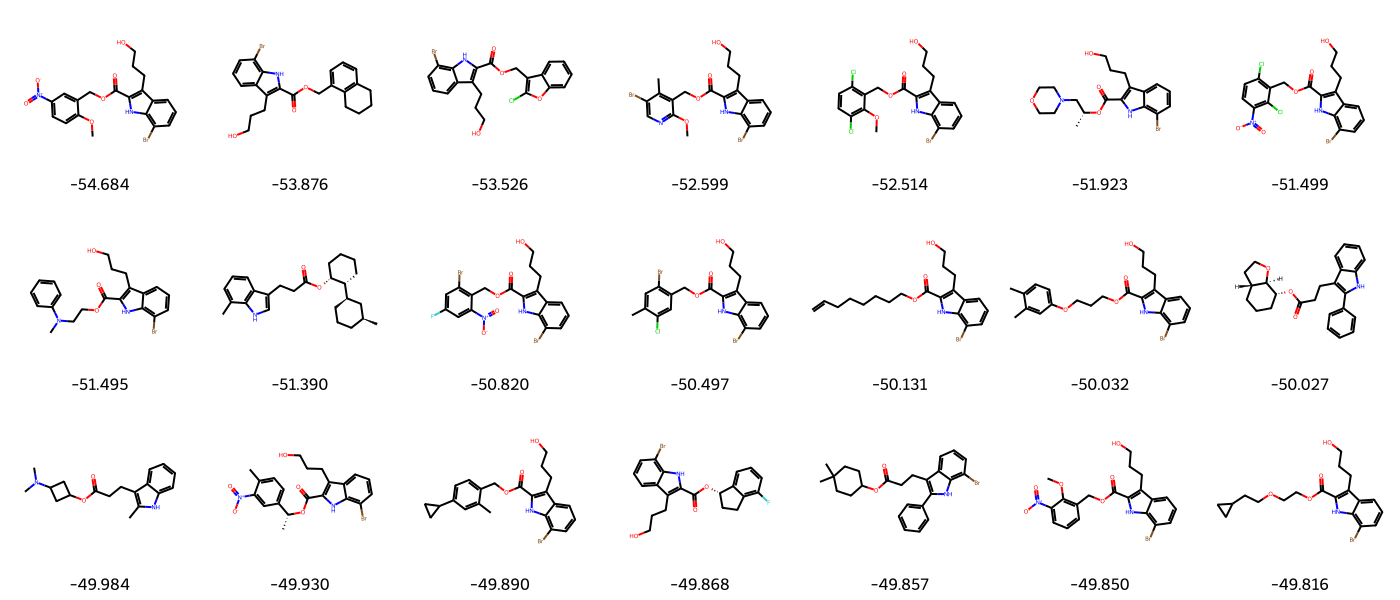

In [18]:
best_gb = df.nsmallest(21, columns="mmgbsa_score")
mols = best_gb["smiles"].map(Chem.MolFromSmiles)
Draw.MolsToGridImage(mols, molsPerRow=7,
    legends=best_gb["mmgbsa_score"].apply(lambda x: f"{x:.3f}").tolist())

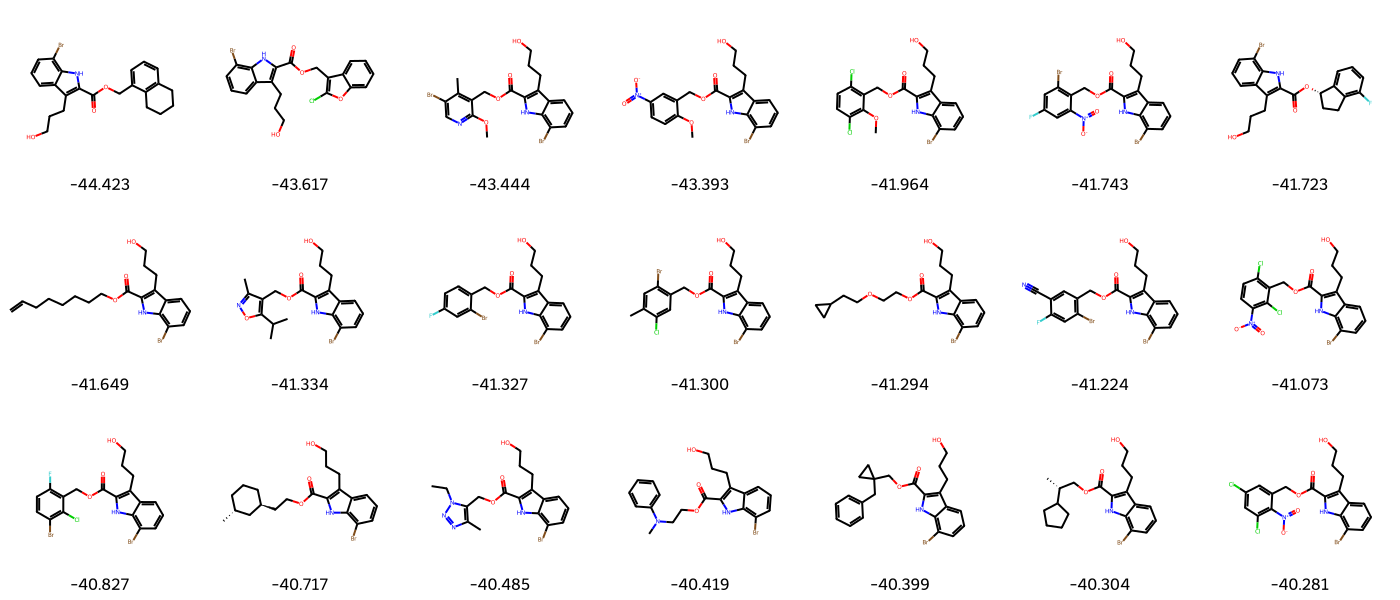

In [19]:
best_pb = df.nsmallest(21, columns="mmpbsa_score")
mols = best_pb["smiles"].map(Chem.MolFromSmiles)
Draw.MolsToGridImage(mols, molsPerRow=7,
    legends=best_pb["mmpbsa_score"].apply(lambda x: f"{x:.3f}").tolist())

The docking score histogram has two clear peaks. In the following we will investigate what might be the cause of this.
In the following we will first fit a gaussian mixture model around the two peaks, assigning each molecule to one of the classes. The resulting two classes require more in depth analysis, for what causes the bimodal distribution

In [20]:
import numpy as np
from scipy.signal import argrelmax
from sklearn.mixture import GaussianMixture

We first find the two relative maxima and then initialize the GMM with those as means.

In [21]:
counts, bins = np.histogram(dock_df["vina_score"].values, bins=50, density=True)
maxima = argrelmax(counts, order=5)
bins[maxima]

array([-9.2482 , -7.78476])

In [22]:
gm = GaussianMixture(n_components=2, means_init=bins[maxima].reshape(-1, 1))
gm.fit(dock_df["vina_score"].values.reshape(-1, 1))

GaussianMixture(means_init=array([[-9.2482 ],
       [-7.78476]]),
                n_components=2)

Let's visulaize the result.

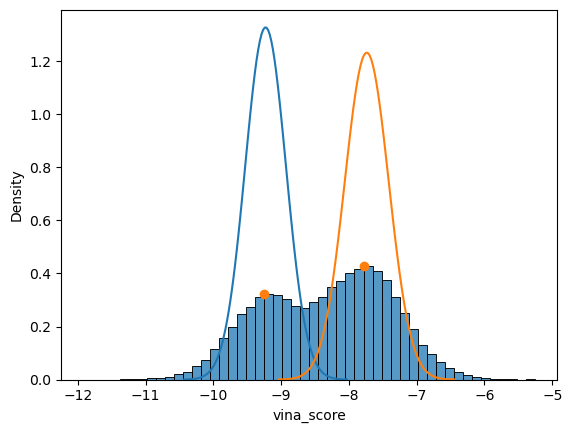

In [23]:
from scipy.stats import norm

ax = sns.histplot(dock_df, x="vina_score", bins=50, stat="density")
plt.scatter(bins[maxima], counts[maxima])

for mu, sigma in zip(gm.means_.flatten(), gm.covariances_.flatten()):
    x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 100)
    ax.plot(x, norm.pdf(x, mu, sigma))

In [24]:
df["mols"] = df["smiles"].map(Chem.MolFromSmiles)
df["class"] = gm.predict(df["vina_score"].values.reshape(-1, 1))

In [25]:
from IPython.display import display

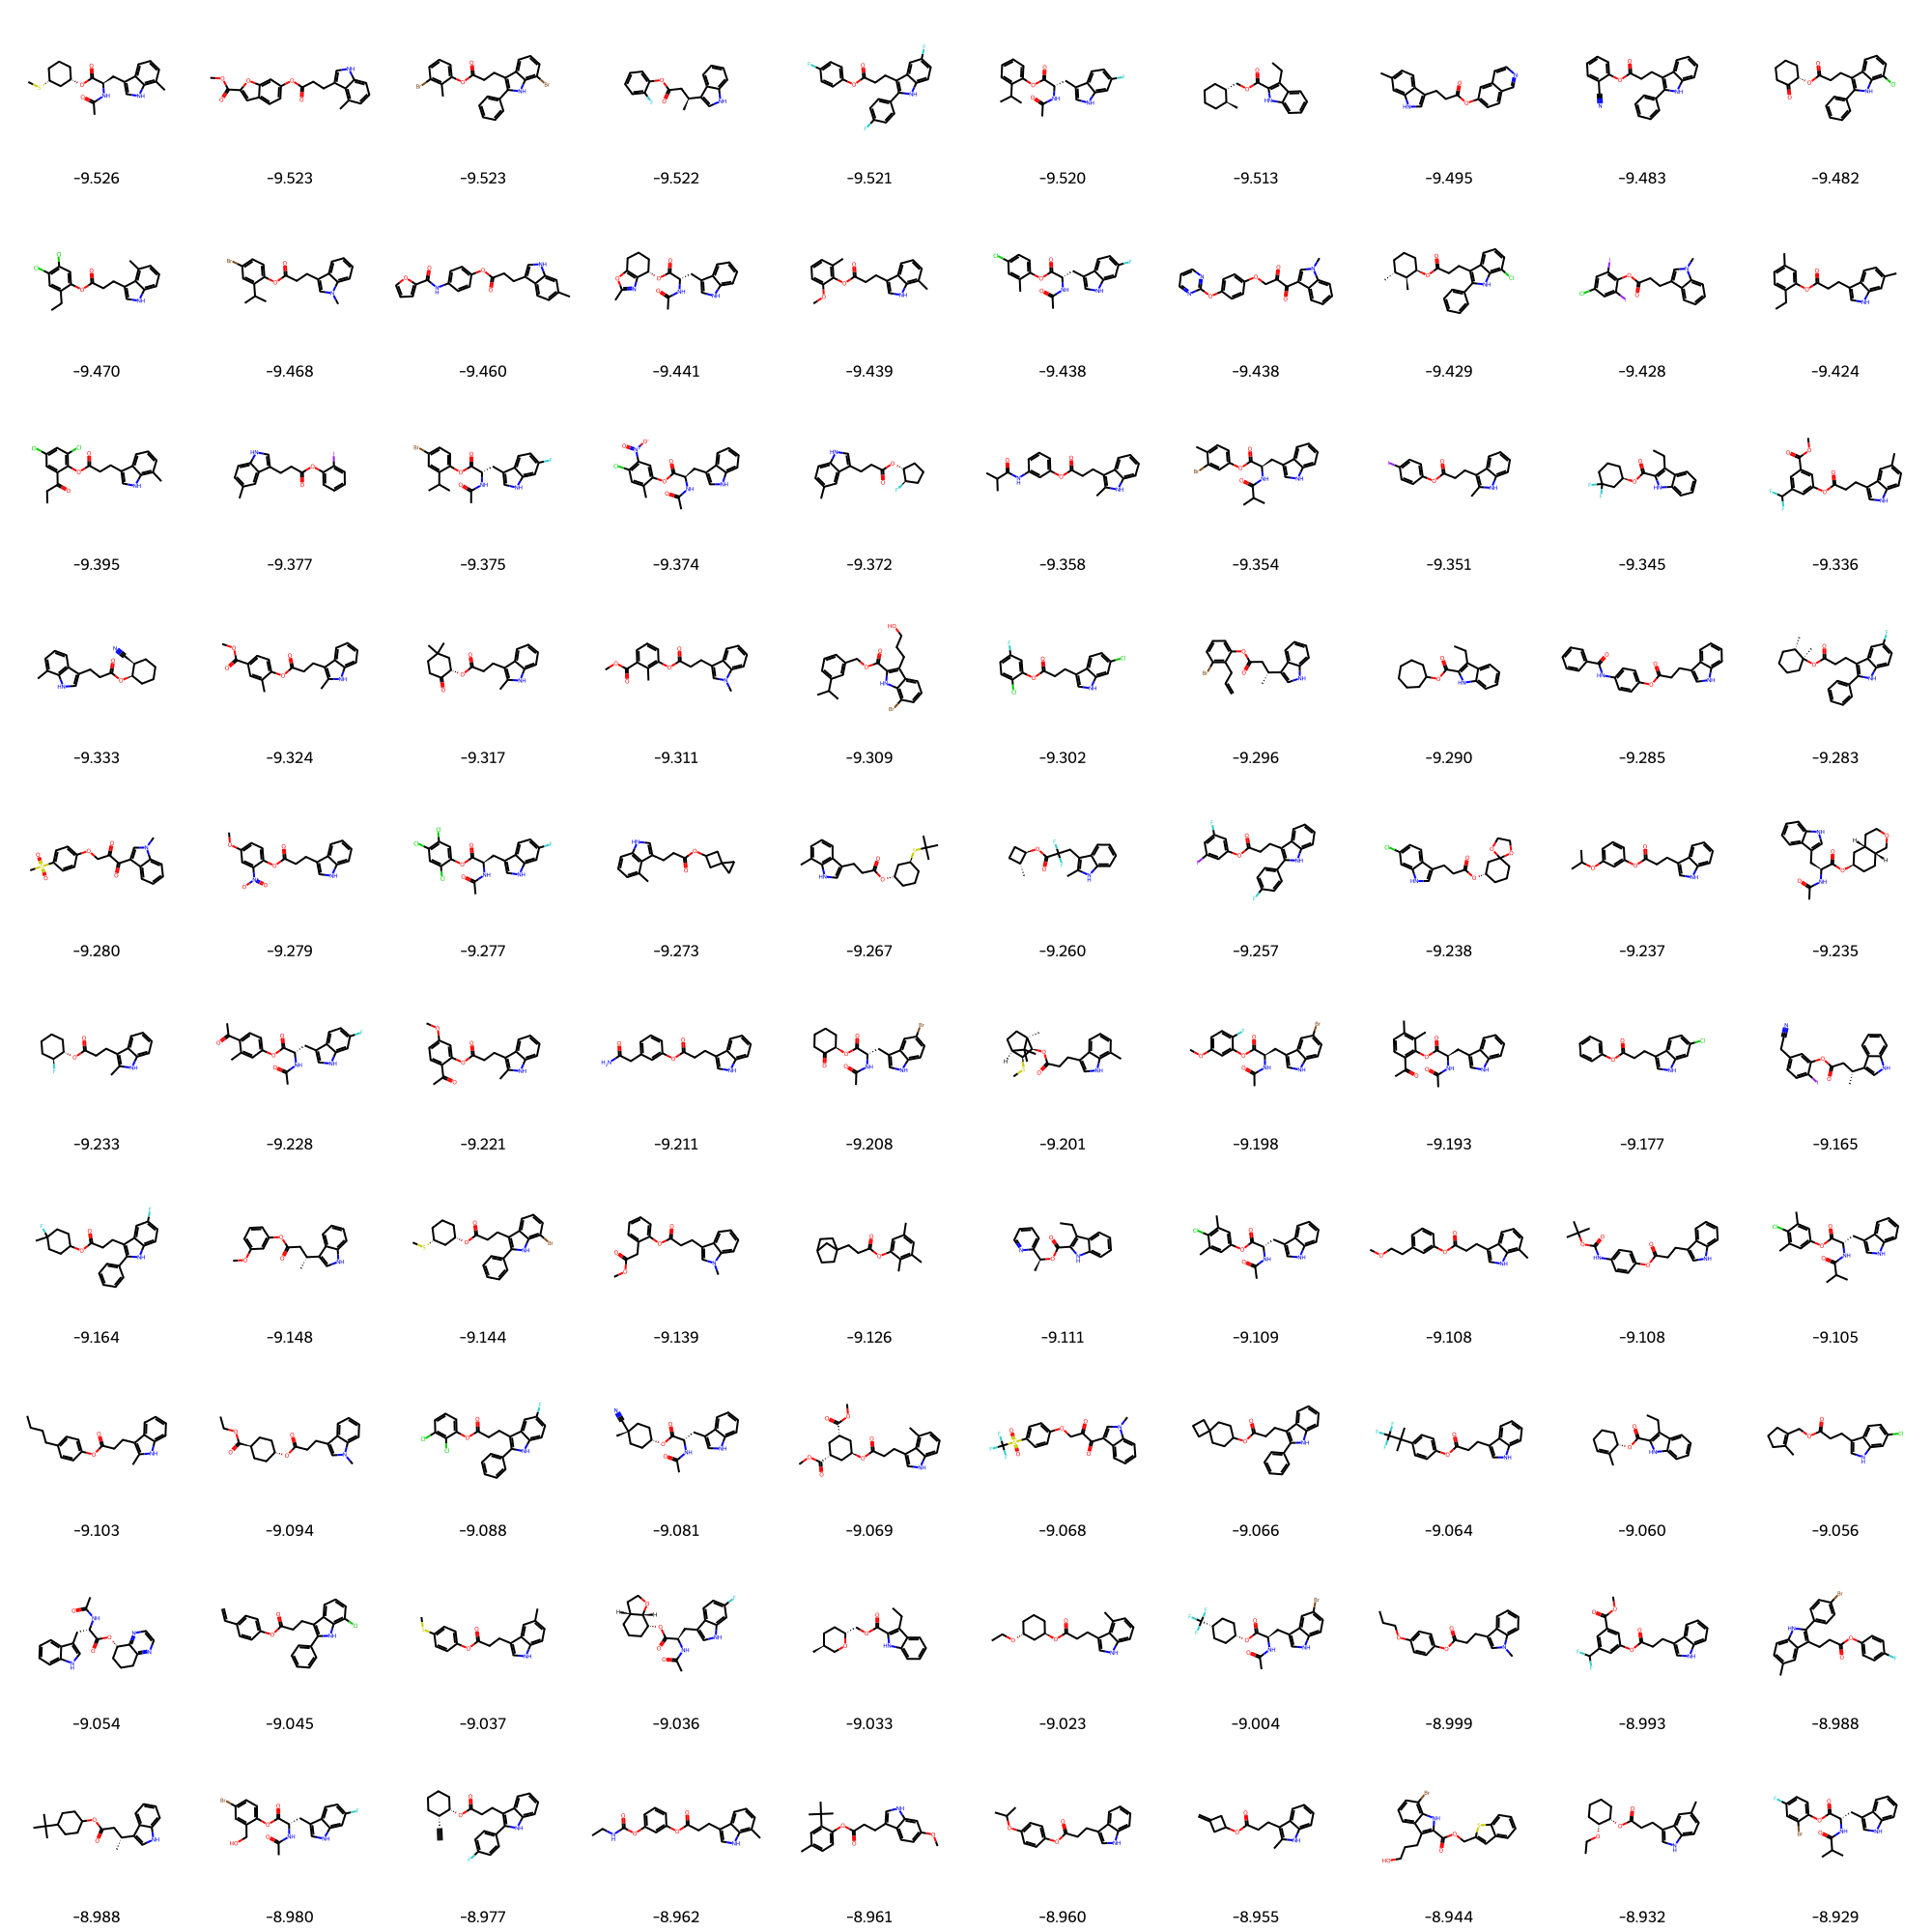

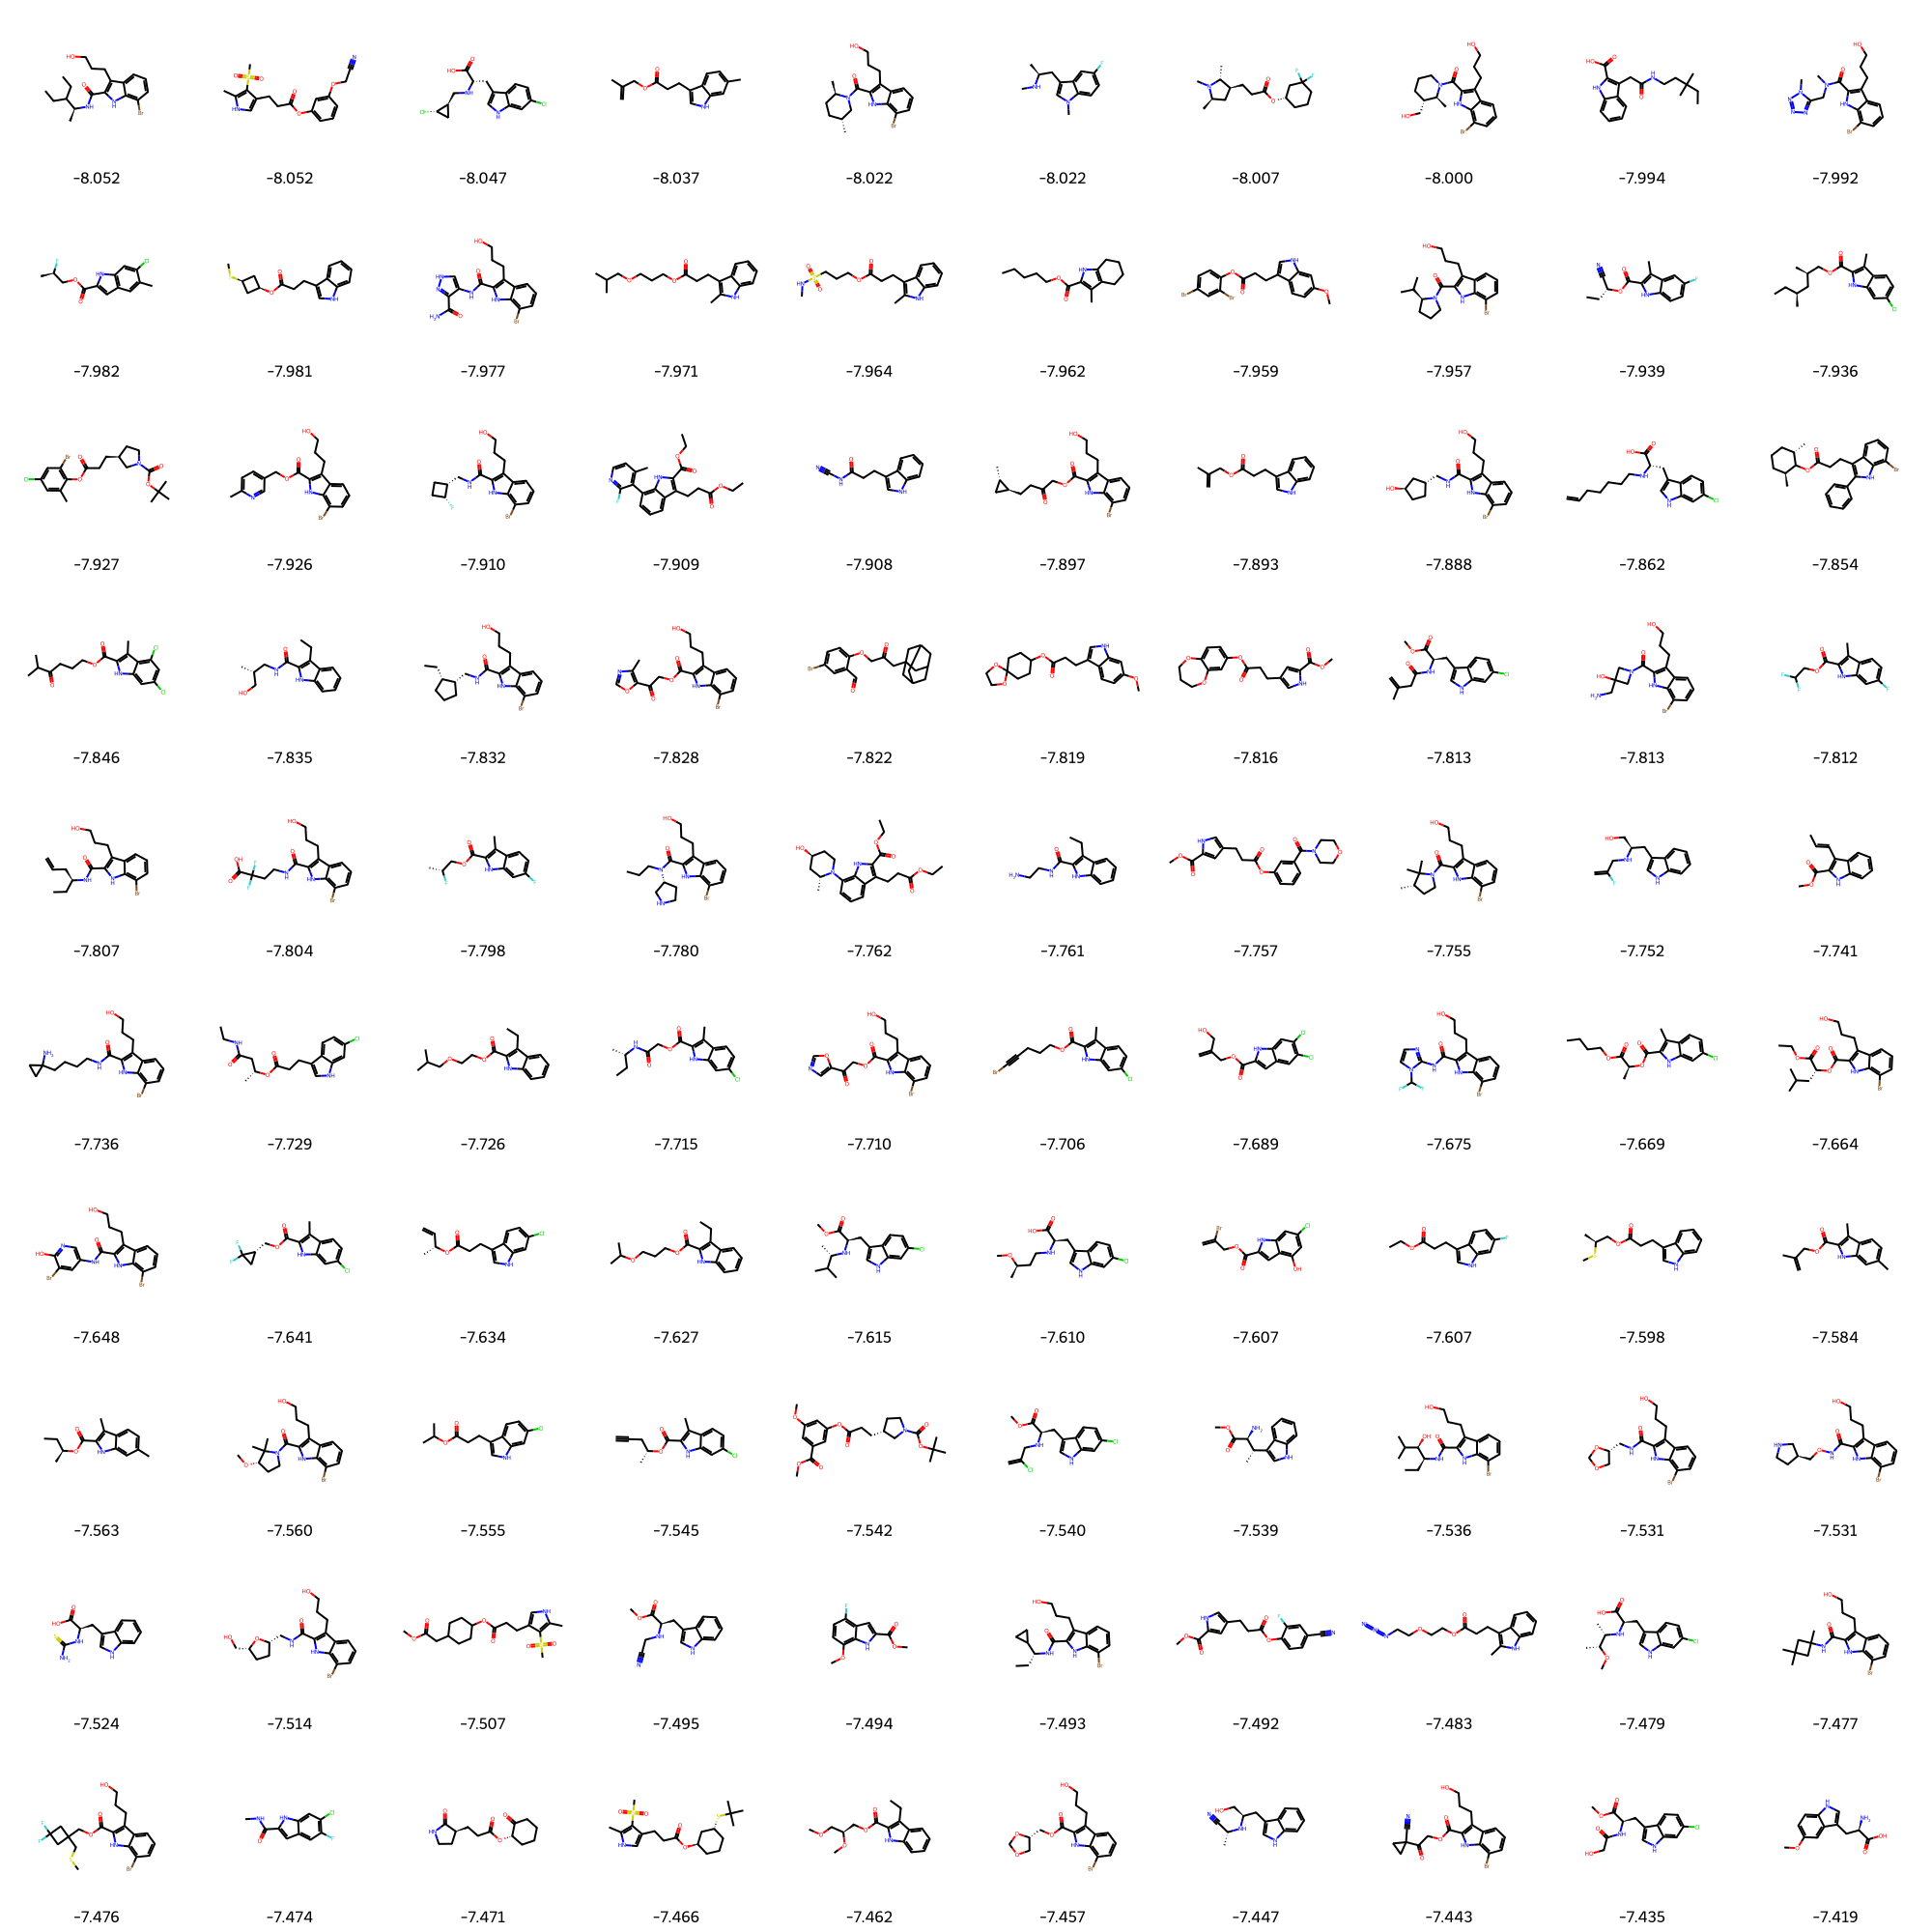

In [26]:
images = []
for c, (mu, sigma) in enumerate(zip(gm.means_.flatten(), gm.covariances_.flatten())):
    lo, up = mu - sigma, mu + sigma
    close = df[
        (df["class"] == c) & (lo <= df["vina_score"]) & (df["vina_score"] <= up)
    ]
    sample = close.sample(100).sort_values(by="vina_score")
    display(
        Draw.MolsToGridImage(
            sample["mols"],
            molsPerRow=10,
            legends=sample["vina_score"].apply(lambda x: f"{x:.3f}").tolist(),
            maxMols=100,
        )
    )